## 1DECISION TREE

#### 1. Data Preparation:

In [3]:
import pandas as pd
import numpy as np

df = pd.read_excel("heart_disease.xlsx", sheet_name=1)
print(df.head())

   age   sex               cp  trestbps  chol    fbs         restecg  thalch  \
0   63  Male   typical angina       145   233   True  lv hypertrophy     150   
1   41  Male  atypical angina       135   203  False          normal     132   
2   57  Male     asymptomatic       140   192  False          normal     148   
3   52  Male   typical angina       118   186  False  lv hypertrophy     190   
4   57  Male     asymptomatic       110   201  False          normal     126   

   exang  oldpeak        slope          thal  num  
0  False      2.3  downsloping  fixed defect    0  
1  False      0.0         flat  fixed defect    0  
2  False      0.4         flat  fixed defect    0  
3  False      0.0         flat  fixed defect    0  
4   True      1.5         flat  fixed defect    0  


#### 2. Exploratory Data Analysis (EDA):

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

print(df.tail())
print("Shape of dataset:", df.shape)

print("Columns:")
print(df.columns)

print(df.info())

print(df.describe())

print(df.dtypes)

print(df.isnull().sum())

print("Duplicate rows:", df.duplicated().sum())

     age   sex            cp  trestbps  chol    fbs           restecg  thalch  \
903   53  Male  asymptomatic       125     0  False            normal     120   
904   62  Male  asymptomatic       166   170  False  st-t abnormality     120   
905   56  Male   non-anginal       170     0  False    lv hypertrophy     123   
906   56  Male   non-anginal       144   208   True  st-t abnormality     105   
907   57  Male  asymptomatic       142   277   True  st-t abnormality     182   

     exang  oldpeak        slope               thal  num  
903  False      1.5    upsloping             normal    4  
904   True      3.0         flat  reversable defect    4  
905   True      2.5  downsloping  reversable defect    4  
906   TURE      NaN  downsloping  reversable defect    4  
907  FALSE      NaN         flat             normal    4  
Shape of dataset: (908, 13)
Columns:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'thal', 'nu

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64


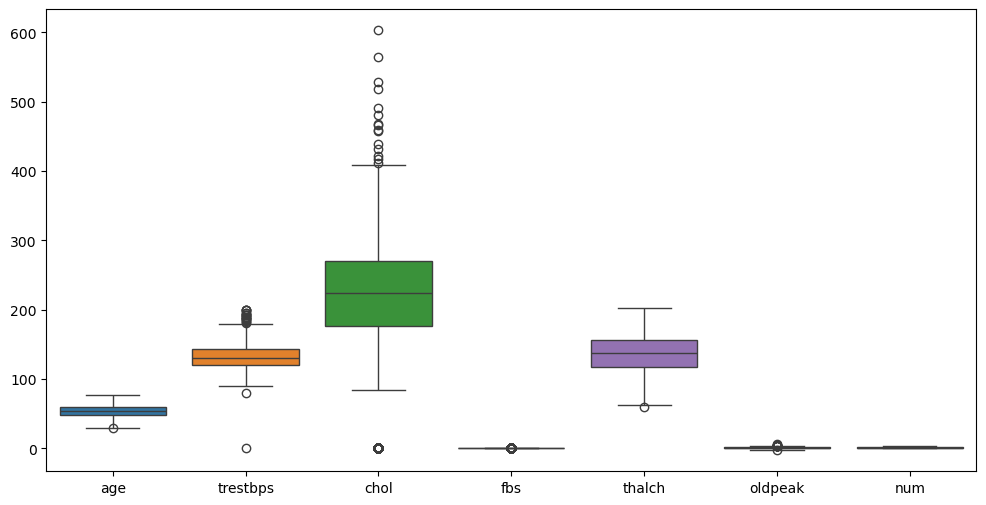

Duplicate Rows: 1


In [6]:
print(df.isnull().sum())

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.show()

print("Duplicate Rows:", df.duplicated().sum())

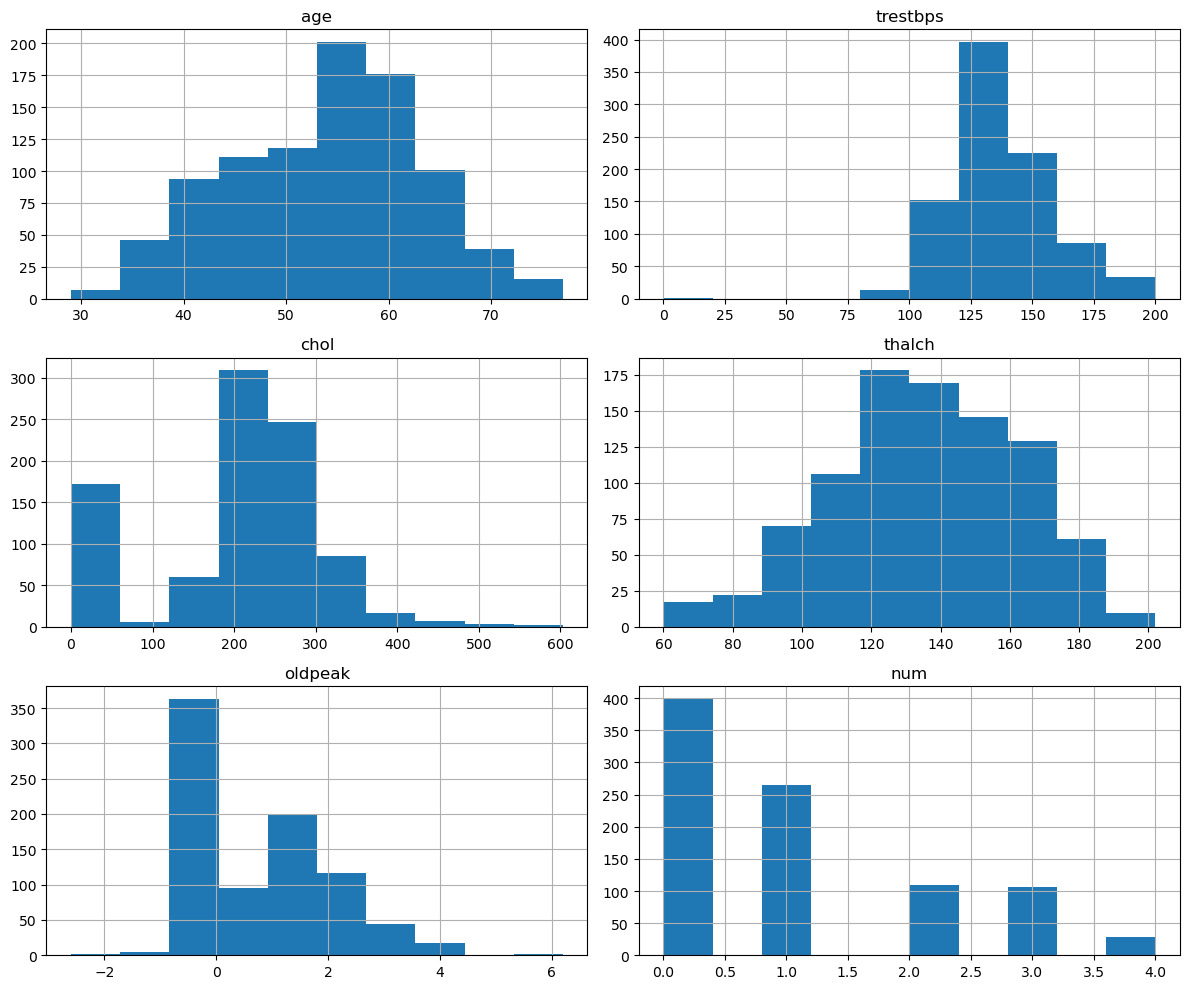

In [7]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

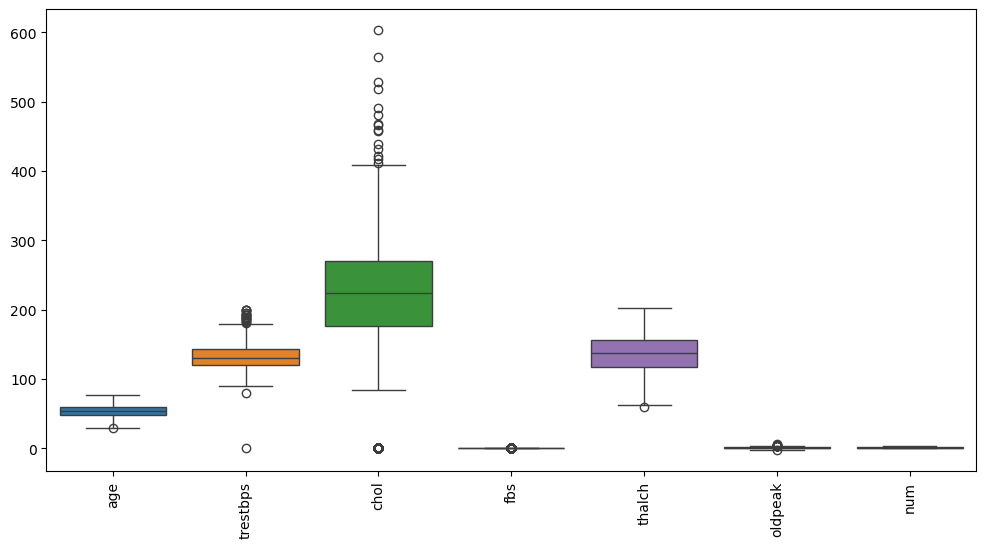

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

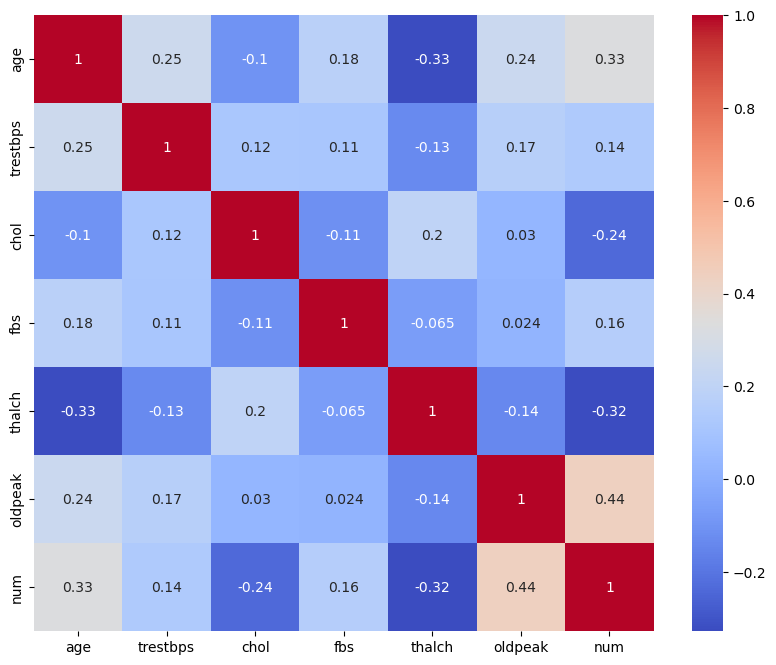

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

#### 3. Feature Engineering:

In [12]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = df.fillna(df.mean(numeric_only=True))

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])

scaler = StandardScaler()

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print(df.head())

        age       sex        cp  trestbps      chol    fbs   restecg  \
0  1.006027  0.514416  2.320276  0.567394  0.281297   True -1.561352   
1 -1.397560  0.514416  0.232258  0.076967  0.013526  False  0.013879   
2  0.350503  0.514416 -0.811752  0.322181 -0.084656  False  0.013879   
3 -0.195767  0.514416  2.320276 -0.756760 -0.138211  False -1.561352   
4  0.350503  0.514416 -0.811752 -1.149102 -0.004325  False  0.013879   

     thalch     exang   oldpeak     slope      thal       num  
0  0.524183 -0.774285  1.334996 -1.672770 -1.553454 -0.881977  
1 -0.147705 -0.774285 -0.844594 -0.224843 -1.553454 -0.881977  
2  0.449529 -0.774285 -0.465535 -0.224843 -1.553454 -0.881977  
3  2.017268 -0.774285 -0.844594 -0.224843 -1.553454 -0.881977  
4 -0.371668  1.260594  0.576878 -0.224843 -1.553454 -0.881977  


#### 4. Decision Tree Classification:

In [16]:
from sklearn.model_selection import train_test_split

# Separate features and target variable
X = df.drop("num", axis=1)
y = df["num"]

# Split the dataset into training and testing sets (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (726, 12)
Testing Features: (182, 12)
Training Target: (726,)
Testing Target: (182,)


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

# Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Separate features and target
X = df.drop("num", axis=1)   # Replace "num" with your target column if different
y = df["num"]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Train Decision Tree Classifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

print("Decision Tree Model Created Successfully")

Decision Tree Model Created Successfully


In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Predict on the testing set
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1-Score:", f1_score(y_test, y_pred, average='weighted'))

# ROC-AUC Score (for binary classification)
if len(y.unique()) == 2:
    y_prob = model.predict_proba(X_test)[:, 1]
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.5164835164835165
Precision: 0.5283388634363287
Recall: 0.5164835164835165
F1-Score: 0.5216234634163536


#### 5. Hyperparameter Tuning:

In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Define the parameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10]
}

# Create the model
dt = DecisionTreeClassifier(random_state=42)

# Perform Grid Search
grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_

# Display best parameters
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 10}
Best Accuracy: 0.5316391119508739


#### 6. Model Evaluation and Analysis:

In [28]:
print("Model Performance Analysis")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1-Score:", f1_score(y_test, y_pred, average='weighted'))

if len(y.unique()) == 2:
    y_prob = model.predict_proba(X_test)[:, 1]
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Model Performance Analysis
Accuracy: 0.5164835164835165
Precision: 0.5283388634363287
Recall: 0.5164835164835165
F1-Score: 0.5216234634163536


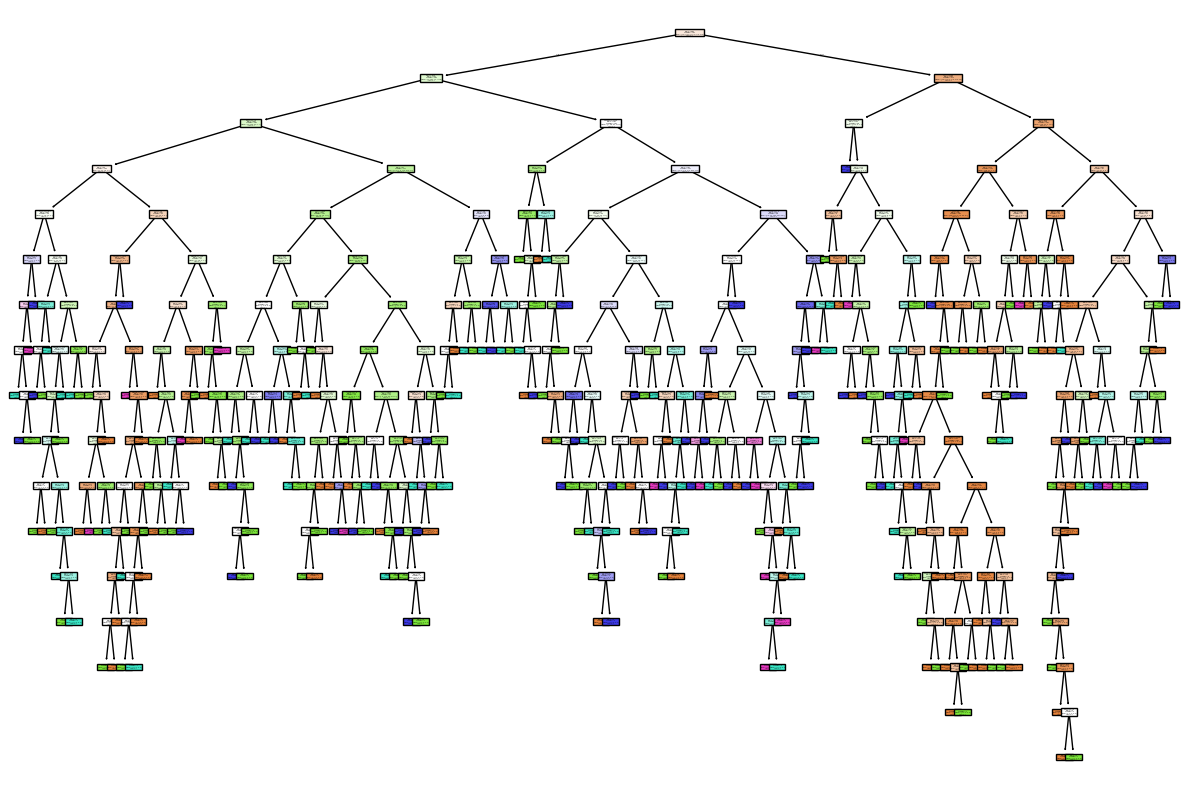

     Feature  Importance
7     thalch    0.157466
4       chol    0.140207
0        age    0.134601
2         cp    0.127762
3   trestbps    0.115532
9    oldpeak    0.098236
6    restecg    0.053592
11      thal    0.045649
1        sex    0.035336
8      exang    0.035238
10     slope    0.032447
5        fbs    0.023932


In [29]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Visualize the Decision Tree
plt.figure(figsize=(15,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=[str(i) for i in model.classes_],
    filled=True
)
plt.show()

# Display Feature Importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

print(feature_importance.sort_values(by="Importance", ascending=False))

#### Interview Questions:

In [ ]:
1. What are some common hyperparameters of Decision Tree models, and how do they affect the model's performance?

max_depth: Controls the maximum depth of the tree. A smaller value reduces overfitting, while a larger value may increase overfitting.
min_samples_split: Specifies the minimum number of samples required to split a node. Higher values make the tree simpler.
min_samples_leaf: Specifies the minimum number of samples required at a leaf node. Higher values help reduce overfitting.
criterion: Determines how the quality of a split is measured.
gini: Uses Gini Impurity.
entropy: Uses Information Gain.
max_features: Limits the number of features considered for each split, which can improve generalization.

In [ ]:
2. What is the difference between Label Encoding and One-Hot Encoding?

Label Encoding
Converts categories into integer values (e.g., Red=0, Blue=1, Green=2).
Suitable for ordinal data where categories have an order.
May introduce an artificial order between categories.
Uses less memory.

One-Hot Encoding
Converts each category into a separate binary column.
Suitable for nominal data where categories have no order.
Does not introduce any order between categories.
Uses more memory because it creates additional columns.